In [1]:
import os
import json
from pathlib import Path

import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.image_utils import load_image

MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"
IMAGE_DIR = "./data"
OUTPUT_FILE = "dataset.jsonl"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
).to(DEVICE)

processor = AutoProcessor.from_pretrained(MODEL_ID)

print("Модель загружена:", MODEL_ID, "| device:", DEVICE)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Модель загружена: HuggingFaceTB/SmolVLM-256M-Instruct | device: cuda


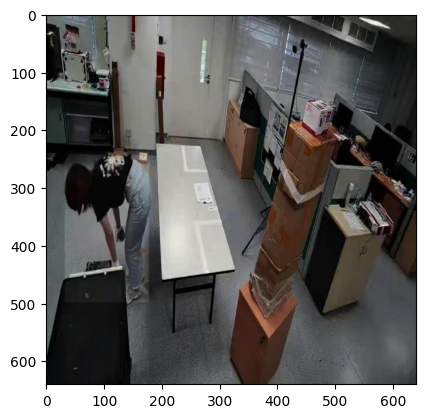

Промпт: How many people are in the frame? Describe them in great detail.
Ответ: [' 1.']


In [5]:
import matplotlib.pyplot as plt
import cv2

TEST_IMAGE = Path("./data/-01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg")  # путь к картинке

image_bgr = cv2.imread(str(TEST_IMAGE))[:, :, ::-1]
plt.imshow(image_bgr)
plt.show()

TEST_PROMPT = "How many people are in the frame? Describe them in great detail."

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

# Загружаем изображение для модели
image = load_image(str(TEST_IMAGE))

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt",
).to(DEVICE)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)


In [8]:
PROMPT = """
Describe the image briefly and informatively.
Specify:
- main objects
- actions
- the stage
Answer in one sentence.
DESCRIBE IN AS MUCH DETAIL AS POSSIBLE, EVERY ELEMENT, EVERY ACTION!!!
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    # Загружаем изображение для модели
    image = load_image(image_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": PROMPT},
            ],
        }
    ]

    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

    inputs = processor(
        text=prompt,
        images=[image],
        return_tensors="pt",
    ).to(DEVICE)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    item = {
        "image": image_path,
        "text": output_text,
    }

    all_items.append(item)

    print(output_text)


Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
 Room.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
 Room.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
 The image depicts a classroom setting with several cardboard boxes prominently displayed. The boxes are positioned in a way that suggests they are intended for distribution or storage purposes. The cardboard appears to be a standard size, possibly a box for shipping or packaging.

In the foreground, there is a large, rectangular cardboard box that is open and has a label on it. The label is prominently displayed, and it reads "FLOWER" in large, bold letters. The letters are in a sans-serif font, and the background of the label is white. The box is open, revealing a glimpse of the interior of the room.

To the left of the box, there is another box, which is also open and has a label on it. This box is also white and has a similar design.

In the backgrou

In [9]:


with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Saved to {OUTPUT_FILE}")


Saved to dataset.jsonl
